In [1]:
# Se carga la librería pandas para el manejo de datos
import pandas as pd
# Se carga la librería seaborn para visualización de datos y matplotlib para mostrar gráficos
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Se carga el archivo CSV con los datos
df_empleados = pd.read_csv(r'data/HR-Employee-Attrition.csv')
df_empleados.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Dimensiones del dataset

In [3]:
# Se usa shape para conocer las dimensiones del DataSet.
df_empleados.shape

(1470, 35)

# Frecuencia Absoluta y Relativa de la variable Attrition

In [4]:
# Frecuencia Absoluta de la variable "Attrition"
df_empleados["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [5]:
# Se saca el total de registros de attrition para calcular la frecuencia relativa.
Total = df_empleados["Attrition"].count()

# Se saca el total de registros por cada valor de attrition para calcular la frecuencia relativa.
valoresAtt = df_empleados["Attrition"].value_counts()

# Se sacan los valores de attrition en Yes y No para calcular la frecuencia relativa.
valoresYes = valoresAtt.iloc[1]
valoresNo = valoresAtt.iloc[0]

# Se calcula la frecuencia relativa de cada valor de attrition.
FrecuenciaRelativaYes = valoresYes / Total
FrecuenciaRelativaNo = valoresNo / Total

# Se muestran las frecuencias relativas de cada valor de attrition.
print("Frecuencia Relativa de Attrition = Yes: ", FrecuenciaRelativaYes)
print("Frecuencia Relativa de Attrition = No: ", FrecuenciaRelativaNo)

Frecuencia Relativa de Attrition = Yes:  0.16122448979591836
Frecuencia Relativa de Attrition = No:  0.8387755102040816


# ¿La distribución es balanceada o desbalanceada? ¿Qué implicaciones tiene esto para un proyecto de clasificación?

La distribución de la variable Attrition es desbalanceada, ya que se visualiza que en Yes, hay 237 empleados, representando un 16% mientras que en No, hay 1233 empleados, siendo este valor un 84% aproximadamente.

Esto quiere decir que para un proyecto de clasificación podría haber underfitting, es decir, que el modelo no tiene los datos suficientes para aprender de manera correcta, por lo cual, es necesario hacer un balanceo.

# Tabla de contingencia entre OverTime y Attrition

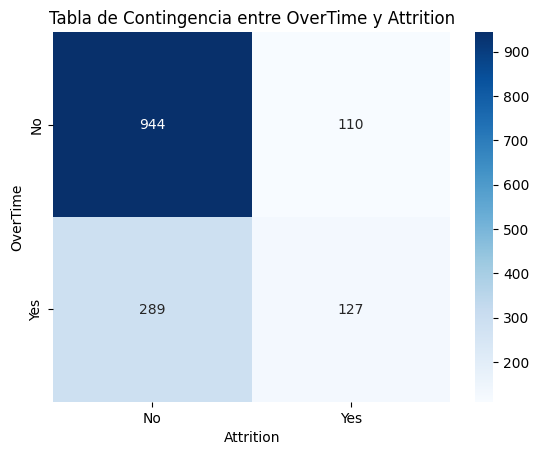

In [6]:
# Se crea una tabla de contingencia entre las variables "OverTime" y "Attrition" con la función crosstab de pandas
tabla = pd.crosstab(df_empleados["OverTime"], df_empleados["Attrition"])

# Se muestra la tabla de contingencia con un mapa de calor utilizando seaborn
sns.heatmap(tabla, cmap="Blues",annot=True,fmt="d")
plt.title("Tabla de Contingencia entre OverTime y Attrition");

# Tabla de probabilidades conjuntas entre Overtime y Attrition

In [7]:
# Cada celda de la tabla de contingencia se divide por el total de registros para obtener la tabla de probabilidades conjuntas
TablaProbConjunta = tabla/tabla.values.sum()
TablaProbConjunta

Attrition,No,Yes
OverTime,,
No,0.642177,0.074830
Yes,0.196599,0.086395


# Tabla de probabilidades condicionales

In [8]:
# Cada celda de la tabla de contingencia se divide por el total de registros por fila para obtener la tabla de probabilidades condicionales
tabla.div(tabla.sum(axis=1),axis=0)

Attrition,No,Yes
OverTime,,
No,0.895636,0.104364
Yes,0.694712,0.305288


# Tabla de probabilidades marginales

In [9]:
# Se calcula la suma total de la tabla de contingencia.
total_tabla = tabla.values.sum()

# Se calcula la suma total de cada fila en la tabla de contingencia.
filas_total = tabla.sum(axis=1)

# Se calcula la suma total de cada columna en la tabla de contingencia.
cols_total = tabla.sum(axis=0)

# Se divide la suma total de cada fila por el total de la tabla para obtener la probabilidad de cada valor de Overtime.
prob_Overtime = filas_total / total_tabla

# Se divide la suma total de cada columna por el total de la tabla para obtener la probabilidad de cada valor de Attrition.
prob_Attrition = cols_total / total_tabla

#se suman las probabilidades de cada valor de Overtime y Attrition para verificar que sumen 1.
suma_prob_Overtime = prob_Overtime.sum()
suma_prob_Attrition = prob_Attrition.sum()

print("Probabilidad de Overtime: \n", prob_Overtime)
print("\nProbabilidad de Attrition: \n", prob_Attrition)

print("\nSuma de Probabilidades de Overtime: ", suma_prob_Overtime)
print("Suma de Probabilidades de Attrition: ", suma_prob_Attrition)

Probabilidad de Overtime: 
 OverTime
No     0.717007
Yes    0.282993
dtype: float64

Probabilidad de Attrition: 
 Attrition
No     0.838776
Yes    0.161224
dtype: float64

Suma de Probabilidades de Overtime:  1.0
Suma de Probabilidades de Attrition:  1.0


In [10]:
# Se guarda la tabla de contingencia con las probabilidades condicionales.
condicionales = tabla.div(tabla.sum(axis=1),axis=0)

# Se toma la columna de Attrition = Yes para obtener la probabilidad condicional de que un empleado tenga attrition dado que hace overtime o no hace overtime.
condicionales.loc[:,"Yes"]

OverTime
No     0.104364
Yes    0.305288
Name: Yes, dtype: float64

# Comparacion condicionales de Attrition en Yes dado Overtime, y probabilidades marginales de Attrition en Yes.

In [11]:
# probabilidad condicional de que un empleado tenga attrition dado que hace overtime o no hace overtime.
print("Probabilidad condicional de que un empleado tenga attrition dado que hace overtime o no hace overtime: \n", condicionales.loc[:,"Yes"])

# probabilidad marginal de attrition = yes
print("Probabilidad marginal de attrition = yes: \n", prob_Attrition.loc["Yes"])

Probabilidad condicional de que un empleado tenga attrition dado que hace overtime o no hace overtime: 
 OverTime
No     0.104364
Yes    0.305288
Name: Yes, dtype: float64
Probabilidad marginal de attrition = yes: 
 0.16122448979591836


Se observa que las personas que no realizaron horas extra presentan una menor probabilidad de attrition en comparación con aquellas que sí realizaron overtime. En particular, la probabilidad condicional de attrition para empleados con overtime es aproximadamente del 30%, mientras que para aquellos sin overtime es cercana al 10.4%.

Por otro lado, la probabilidad marginal de attrition es del 16%, lo que indica que, del total de la muestra, el 16% de los empleados experimentaron attrition. Al comparar este valor con las probabilidades condicionales, se evidencia que la proporción de attrition es significativamente mayor en el grupo de empleados que realizan horas extra.

En consecuencia, se puede inferir que el overtime podría estar asociado con un mayor riesgo de attrition. No obstante, esta relación no implica causalidad, ya que pueden existir otros factores que también influyan en la deserción, como se observa en el hecho de que algunos empleados sin overtime también presentan attrition.

# Validacion de independencia entre Attrition y Overtime

In [12]:
# se calcula la probabilidad conjunta de que un empleado tenga attrition = yes y haga overtime = yes 
# dividiendo la celda correspondiente de la tabla de contingencia por el total de la tabla.
p_conjunta = tabla.loc["Yes", "Yes"] / total_tabla

# Probabilidad marginal de attrition = yes y de overtime = yes
p_attrition = tabla["Yes"].sum() / total_tabla  
p_overtime = tabla.loc["Yes"].sum() / total_tabla

# Se multiplican las probabilidades marginales de attrition = yes y de overtime = yes para obtener la probabilidad conjunta bajo la suposición de independencia.
p_producto = p_attrition * p_overtime

print("Probabilidad conjunta de que un empleado tenga attrition = yes y haga overtime = yes: ", p_conjunta)
print("Producto de las probabilidades marginales de attrition = yes y de overtime = yes: ", p_producto)

Probabilidad conjunta de que un empleado tenga attrition = yes y haga overtime = yes:  0.08639455782312926
Producto de las probabilidades marginales de attrition = yes y de overtime = yes:  0.04562543384700819


Al comparar la probabilidad conjunta de que un empleado presente *attrition* y realice horas extra (aproximadamente 8%) con el producto de las probabilidades marginales correspondientes (aproximadamente 4%), se observa una diferencia significativa entre ambos valores. Dado que, bajo independencia, debe cumplirse que 

$P(A \cap B) = P(A)\cdot P(B)$ 

Esta discrepancia indica que las variables *Attrition* y *OverTime* no son independientes.

# Tabla de contingencia Departments vs Attrition

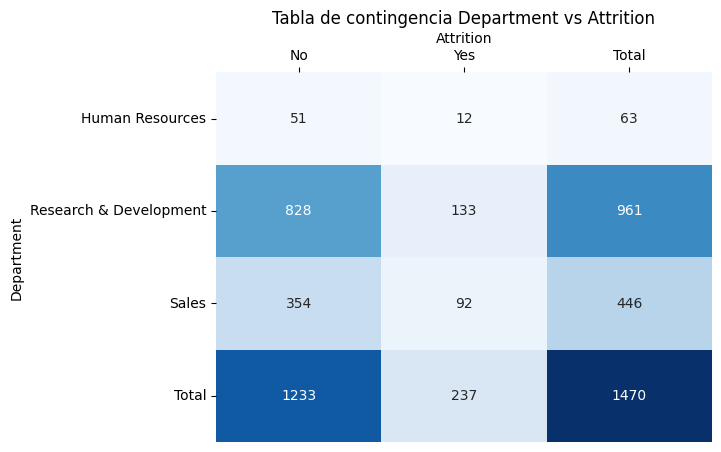

In [13]:
# Se crea la tabla de contingencia de Department vs Attrition con frecuencias absolutas y frecuencias marginales.
tabla_d_a = pd.crosstab(df_empleados["Department"], df_empleados["Attrition"],margins=True, margins_name="Total")

# Se guarda el grafico heatmap en la variable ax, con el fin de aplicar propiedades visuales.
ax = sns.heatmap(tabla_d_a, cmap="Blues", annot=True, fmt="d",cbar=False)

ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

plt.title("Tabla de contingencia Department vs Attrition");

# Probabilidades conjuntas, marginales y condicionales P(Att=Yes|Dept)

In [25]:
tabla_d_a_sin_total = pd.crosstab(df_empleados["Department"], df_empleados["Attrition"])
# Se crea la tabla de probabilidades conjuntas entre Department y Attrition.
TablaProbConjunta_D_A = (tabla_d_a_sin_total/tabla_d_a_sin_total.values.sum())*100
suma_prob_conjunta_D_A = TablaProbConjunta_D_A.values.sum()
print(suma_prob_conjunta_D_A)
TablaProbConjunta_D_A

100.0


Attrition,No,Yes
Department,,
Human Resources,3.469388,0.816327
Research & Development,56.326531,9.047619
Sales,24.081633,6.258503


In [26]:
# Se calcula la suma total de la tabla de contingencia.
total_tabla_D_A = tabla_d_a.values.sum()

# Se calcula la suma total de cada fila en la tabla de contingencia.
filas_total_D_A = tabla_d_a.sum(axis=1)

# Se calcula la suma total de cada columna en la tabla de contingencia.
cols_total_D_A = tabla_d_a.sum(axis=0)

# Se divide la suma total de cada fila por el total de la tabla para obtener la probabilidad de cada valor de Overtime.
prob_Department_D_A = filas_total_D_A / total_tabla_D_A

# Se divide la suma total de cada columna por el total de la tabla para obtener la probabilidad de cada valor de Attrition.
prob_Attrition_D_A = cols_total_D_A / total_tabla_D_A

# se imprime la probabilidad conjunta de cada valor de Department y Attrition.
print("Probabilidad de Department: \n", prob_Department_D_A)
print("\nProbabilidad de Attrition: \n", prob_Attrition_D_A)

Probabilidad de Department: 
 Department
Human Resources           0.021429
Research & Development    0.326871
Sales                     0.151701
Total                     0.500000
dtype: float64

Probabilidad de Attrition: 
 Attrition
No       0.419388
Yes      0.080612
Total    0.500000
dtype: float64


In [ ]:
# Se crea la tabla de probabilidades condicionales entre Department y Attrition.
tabla_condicional = tabla_d_a_sin_total.div(tabla_d_a_sin_total.sum(axis=1), axis=0)
tabla_condicional * 100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


# ¿En cuál departamento es más probable la deserción?

Con base en las probabilidades condicionales calculadas, el departamento con mayor probabilidad de deserción es Sales, con una tasa aproximada del 20.63%. Esto indica que, dentro de este departamento, una mayor proporción de empleados presenta attrition en comparación con Human Resources (19.05%) y Research & Development (13.84%).

Por lo tanto, el área de Sales representa el mayor nivel de riesgo relativo de deserción entre los departamentos analizados.

In [1]:
print ('Hola')

Hola
